In [61]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("bsthere/youtube-trending-videos-stats-2026")

print("Path to dataset files:", path)

Path to dataset files: /Users/yiyeekong/.cache/kagglehub/datasets/bsthere/youtube-trending-videos-stats-2026/versions/3


In [62]:

print(os.listdir(path))

['CA_Trending.csv', 'RU_Trending.csv', 'US_Trending.csv', 'MX_Trending.csv', 'FR_Trending.csv', 'BR_Trending.csv', 'data_dictionary.csv', 'GB_Trending.csv', 'DE_Trending.csv', 'KR_Trending.csv', 'IN_Trending.csv', 'JP_Trending.csv']


In [63]:
import pandas as pd
us_file_path = os.path.join(path, "US_Trending.csv")
in_file_path = os.path.join(path, "IN_Trending.csv")
br_file_path  = os.path.join(path, "BR_Trending.csv")
df_us = pd.read_csv(us_file_path)
df_in = pd.read_csv(in_file_path)
df_br = pd.read_csv(br_file_path)

In [ ]:

df_us.info()
df_us.describe()
df_us.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 16199 entries, 0 to 16198
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   video_id       16199 non-null  str  
 1   trending_date  16199 non-null  str  
 2   title          16199 non-null  str  
 3   channel_title  16199 non-null  str  
 4   views          16199 non-null  int64
 5   likes          16199 non-null  int64
 6   dislikes       16199 non-null  int64
 7   publish_time   16199 non-null  str  
 8   category_id    16199 non-null  int64
 9   tags           16199 non-null  str  
 10  comments       16199 non-null  int64
 11  channel_id     16199 non-null  str  
 12  description    14852 non-null  str  
dtypes: int64(5), str(8)
memory usage: 1.6 MB


video_id            0
trending_date       0
title               0
channel_title       1
views               0
likes               0
dislikes            0
publish_time        0
category_id         0
tags                0
comments            0
channel_id          0
description      2820
dtype: int64

In [65]:
# show row with NaN in channel_title
null = df_us[df_us["channel_title"].isnull()]
null

,video_id,trending_date,title,channel_title,views,likes,dislikes,publish_time,category_id,tags,comments,channel_id,description
356,cey-eQMvqDE,26.26.02,After Life | Tony Gets Mugged… Then Drops a Th...,NaN,1553466,40668,0,2026-02-22T13:26:32Z,1,[none],435,UCC5i6mbHDaX5H1-KFGkOH9A,"In After Life, Tony is walking home when two t..."


In [ ]:
# view duplicate rows
df_us.duplicated().sum()

np.int64(0)

In [67]:
video_count = df_us.groupby("video_id").size().sort_values(ascending=False)
print(video_count)

video_id
--5QdQtkgt8    1
e-5pVOA5hvg    1
eYGZbgbAecQ    1
eYNafGydfEY    1
eY_6559ghv8    1
              ..
KB7mylpYxZA    1
KBEXCqufCwI    1
KBVoRuTO0Kk    1
KBvFhS4BH54    1
zzyEWu1NHxw    1
Length: 16400, dtype: int64


In [68]:
# percentage of us videos with no tags
df_us_notag = df_us[df_us["tags"]=="[none]"]
(len(df_us_notag)/len(df_us))*100

29.21341463414634

In [69]:

df_in_notag = df_in[df_in["tags"] == "[none]"]
(len(df_in_notag)/len(df_in))*100

17.08130131489598

In [70]:
df_br_notag = df_br[df_br["tags"] == "[none]"]  
(len(df_br_notag)/len(df_br))*100

25.154320987654323

In [72]:
# parse date for df_us

# publish_time is ISO 8601 with timezone
df_us["publish_time"] = pd.to_datetime(df_us["publish_time"], utc = True)

# trending_date format is YY.DD.MM 
df_us["trending_date_parsed"] = pd.to_datetime(
    df_us["trending_date"].str.replace(
        r"(\d+)\.(\d+)\.(\d+)", r"20\1-\3-\2", regex=True
    ),
    utc=True,
    errors="coerce",
)


In [74]:
# feature engineering df_us
import numpy as np

# Velocity: how many days from upload to hitting trending
df_us["days_to_trend"] = (
    df_us["trending_date_parsed"] - df_us["publish_time"]
).dt.days.clip(lower=0)  # clip negatives (same-day uploads with timezone edge cases)
 
# Engagement ratios (guard against division by zero)
df_us["like_rate"]    = df_us["likes"] / df_us["views"].replace(0, np.nan)
df_us["comment_rate"] = df_us["comments"] / df_us["views"].replace(0, np.nan)
 
# Tags presence flag
df_us["has_tags"] = (df_us["tags"] != "[none]").astype(int)
 
# Tag count (number of individual tags, 0 if none)
df_us["tag_count"] = df_us["tags"].apply(
    lambda x: len(str(x).split("|")) if x != "[none]" else 0
)
 
# Publish hour (UTC) — captures upload timing strategy
df_us["publish_hour"] = df_us["publish_time"].dt.hour
 
# Publish day of week (0=Monday, 6=Sunday)
df_us["publish_dow"] = df_us["publish_time"].dt.dayofweek
 
# Log-transform views and likes to reduce skew
# (a video with 1B views shouldn't dominate the model)
df_us["log_views"]    = np.log1p(df_us["views"])
df_us["log_likes"]    = np.log1p(df_us["likes"])
df_us["log_comments"] = np.log1p(df_us["comments"])
 

In [75]:
#Velocity bucket (for human-readable timing window in the UI)
bins   = [-1, 0, 1, 3, 7, 30, 365, 99999]
labels = ["same_day", "1_day", "2_3_days", "4_7_days",
          "8_30_days", "1_12_months", "1_plus_year"]
df_us["velocity_bucket"] = pd.cut(
    df_us["days_to_trend"], bins=bins, labels=labels)

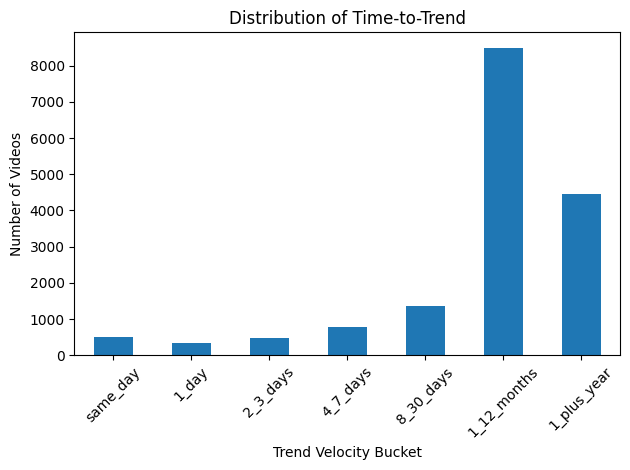

In [76]:
import matplotlib.pyplot as plt

counts = df_us["velocity_bucket"].value_counts().sort_index()
plt.figure()
counts.plot(kind="bar")

plt.xlabel("Trend Velocity Bucket")
plt.ylabel("Number of Videos")
plt.title("Distribution of Time-to-Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
# Target variable for supervised classifier
# Label = 1 if video is in top 25% by views WITHIN its category
# (so a niche category video isn't unfairly penalised vs mainstream)

df_us["view_threshold"] = df_us.groupby("category_id")["views"].transform(
    lambda x: x.quantile(0.75)
)
df_us["label"] = (df_us["views"] >= df_us["view_threshold"]).astype(int)

In [89]:
# CLASSIFIER features: only signals known BEFORE publishing 
# log_views / log_likes / log_comments deliberately excluded —
# those are outcome variables a creator cannot know before uploading
CLASSIFIER_FEATURES = [
    "category_id",   # content niche
    "days_to_trend", # velocity — how fast it hit trending
    "like_rate",     # engagement quality
    "comment_rate",  # discussion depth
    "has_tags",      # tagging strategy (binary)
    "tag_count",     # number of tags used
    "publish_hour",  # upload timing
    "publish_dow",   # upload day of week
]
 
# ── CLUSTERING features: describes archetypes — outcome signals allowed ───────
CLUSTER_FEATURES = [
    "days_to_trend", "like_rate", "comment_rate",
    "log_views", "has_tags", "tag_count",
]
 
# Deduplicate columns before building df_model (overlapping feature lists
# would create duplicate pandas columns and corrupt slicing)
all_cols = list(dict.fromkeys(CLASSIFIER_FEATURES + CLUSTER_FEATURES + ["label"]))
 
df_us_model = df_us[all_cols].dropna().copy()
X_clf = df_us_model[CLASSIFIER_FEATURES]
X_clu = df_us_model[CLUSTER_FEATURES]
y     = df_us_model["label"]
 
print("=" * 60)
print("FEATURE MATRIX")
print("=" * 60)
print(f"  Classifier features ({len(CLASSIFIER_FEATURES)}): {CLASSIFIER_FEATURES}")
print(f"  Clustering features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}")
print(f"  Rows after dropna   : {len(df_us_model):,}")
print(f"  Class balance       : worth={y.mean():.1%}  not_worth={1-y.mean():.1%}\n")

FEATURE MATRIX
  Classifier features (8): ['category_id', 'days_to_trend', 'like_rate', 'comment_rate', 'has_tags', 'tag_count', 'publish_hour', 'publish_dow']
  Clustering features (6): ['days_to_trend', 'like_rate', 'comment_rate', 'log_views', 'has_tags', 'tag_count']
  Rows after dropna   : 16,373
  Class balance       : worth=25.1%  not_worth=74.9%



In [82]:
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [90]:
# PART A — UNSUPERVISED: K-MEANS CLUSTERING (trend archetypes)
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("PART A — K-MEANS CLUSTERING")
print("=" * 60)
 
# K-means is distance-based — scale so no feature dominates by unit size
scaler_km        = StandardScaler()
X_cluster_scaled = scaler_km.fit_transform(X_clu)
 
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_us_model["cluster"] = kmeans.fit_predict(X_cluster_scaled)
 
# Invert scaling to read centroids in original units
centroids = pd.DataFrame(
    scaler_km.inverse_transform(kmeans.cluster_centers_),
    columns=CLUSTER_FEATURES
)
 
# Auto-name by ascending days_to_trend (slowest → fastest velocity)
velocity_order = centroids["days_to_trend"].argsort().values
ARCHETYPE_NAMES = {
    int(cid): name
    for name, cid in zip(
        ["Flash Viral", "Fast Mover", "Mid-Burn Trending",
         "Sustained Grower", "Legacy Evergreen"],
        velocity_order
    )
}
df_us_model["archetype"] = df_us_model["cluster"].map(ARCHETYPE_NAMES)
 
print("\nCluster centroids (original scale):")
print(centroids.round(2).to_string())
print("\nArchetype distribution:")
print(df_us_model["archetype"].value_counts().to_string())
print("\n% labelled worth-joining per archetype:")
print(df_us_model.groupby("archetype")["label"].mean().round(3).to_string())
 

PART A — K-MEANS CLUSTERING

Cluster centroids (original scale):
   days_to_trend  like_rate  comment_rate  log_views  has_tags  tag_count
0         206.96       0.04           0.0       9.24       1.0      16.40
1         265.53       0.04           0.0      12.38      -0.0       0.00
2          12.00    1258.80          62.4       2.40       0.0       0.00
3         389.03       0.04           0.0      13.44       1.0      17.17
4        4465.85       0.01           0.0      14.58       1.0      13.38

Archetype distribution:
archetype
Sustained Grower     6908
Mid-Burn Trending    4768
Fast Mover           4272
Legacy Evergreen      424
Flash Viral             1

% labelled worth-joining per archetype:
archetype
Fast Mover           0.000
Flash Viral          0.000
Legacy Evergreen     0.693
Mid-Burn Trending    0.308
Sustained Grower     0.339


In [92]:
# PART B — CATBOOST-STYLE CLASSIFIER
#
# Using sklearn HistGradientBoostingClassifier — same histogram-
# based algorithm as CatBoost / LightGBM: native NaN handling,
# fast on tabular data, strong regularisation.

print("\n" + "=" * 60)
print("PART B — CATBOOST-STYLE CLASSIFIER (HistGradientBoosting)")
print("=" * 60)
 
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.2, random_state=42, stratify=y
)
 
clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", HistGradientBoostingClassifier(
        max_iter=300,           # number of boosting rounds
        learning_rate=0.05,     # shrinks each tree's contribution
        max_depth=4,            # shallow trees — less overfitting
        min_samples_leaf=20,    # minimum samples per leaf
        l2_regularization=1.0,  # L2 penalty on leaf values
        random_state=42,
    )),
])
 
clf_pipeline.fit(X_train, y_train)
y_pred      = clf_pipeline.predict(X_test)
y_pred_prob = clf_pipeline.predict_proba(X_test)[:, 1]
 
print("\nClassification report:")
print(classification_report(y_test, y_pred,
      target_names=["not worth", "worth joining"]))
 
auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC score : {auc:.3f}  (0.5 = random, 1.0 = perfect)")
 
cv_scores = cross_val_score(clf_pipeline, X_clf, y, cv=5, scoring="roc_auc")
print(f"5-fold CV AUC : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
 
# Permutation importance — more reliable than tree-based importance
perm = permutation_importance(
    clf_pipeline, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc"
)
feat_imp = pd.Series(
    perm.importances_mean, index=CLASSIFIER_FEATURES
).sort_values(ascending=False)
 
print("\nPermutation feature importances (drop in AUC when shuffled):")
for feat, imp in feat_imp.items():
    bar = "x" * max(0, int(imp * 300))
    print(f"  {feat:<18} {imp:.4f}  {bar}")

from catboost import CatBoostClassifier

CAT_FEATURES = ["category_id", "has_tags", "publish_dow"]

clf_pipeline = Pipeline([
    ("clf", CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=4,
        l2_leaf_reg=3,
        cat_features=CAT_FEATURES,  # CatBoost encodes these natively
        eval_metric="AUC",
        verbose=0,
        random_seed=42,
    )),
])
clf_pipeline.fit(X_train, y_train)


PART B — CATBOOST-STYLE CLASSIFIER (HistGradientBoosting)

Classification report:
               precision    recall  f1-score   support

    not worth       0.85      0.96      0.90      2454
worth joining       0.79      0.49      0.60       821

     accuracy                           0.84      3275
    macro avg       0.82      0.72      0.75      3275
 weighted avg       0.83      0.84      0.82      3275

ROC-AUC score : 0.871  (0.5 = random, 1.0 = perfect)
5-fold CV AUC : 0.501 +/- 0.144

Permutation feature importances (drop in AUC when shuffled):
  days_to_trend      0.1779  xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
  category_id        0.0902  xxxxxxxxxxxxxxxxxxxxxxxxxxx
  comment_rate       0.0891  xxxxxxxxxxxxxxxxxxxxxxxxxx
  like_rate          0.0714  xxxxxxxxxxxxxxxxxxxxx
  tag_count          0.0626  xxxxxxxxxxxxxxxxxx
  publish_hour       0.0341  xxxxxxxxxx
  publish_dow        0.0020  
  has_tags           0.0010  


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
